This is the same code but with changes to fix computational issues that are arising when I increase L=50 to L=80

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import default_rng
from scipy.optimize import minimize_scalar
import matplotlib.cm as cm
import itertools
from itertools import combinations
from joblib import Parallel, delayed
import pickle

from mpl_toolkits.mplot3d import Axes3D
from scipy.optimize import root_scalar
from scipy.sparse.linalg import eigsh
from scipy.linalg import sqrtm
from scipy.sparse import csr_matrix, lil_matrix
from collections import defaultdict
from scipy.sparse.linalg import expm_multiply
from scipy.linalg import svd
from scipy.optimize import curve_fit
from scipy.optimize import brentq
from scipy.linalg import logm, sqrtm, expm
from qutip import *
from math import comb
import itertools
from scipy.integrate import solve_ivp
import pandas as pd
from numpy.lib.stride_tricks import sliding_window_view


Essential Functions

In [2]:
def generate_particle_basis(L, N):
    """All bitstrings of length L with exactly N ones (as ints)."""
    return [sum(1 << i for i in combo) for combo in itertools.combinations(range(L), N)]

def create_bosonic_H_GUE(L, num_particles=2, max_occupancy=None, scale=1.0, seed=None):
    """
    Create a Gaussian Unitary Ensemble (GUE) Hamiltonian in the bosonic basis.

    Parameters
    ----------
    L : int
        Number of lattice sites.
    num_particles : int
        Total number of bosons.
    max_occupancy : int or None
        Maximum occupancy per site (default: num_particles).
    scale : float
        Overall energy scale (sets the standard deviation of matrix elements).
    seed : int or None
        Random seed for reproducibility.

    Returns
    -------/
    H : np.ndarray
        Hermitian random matrix (GUE) of shape (dim, dim).
    basis : list of tuples
        Bosonic Fock basis in same ordering as the Hamiltonian.
    """
    rng = np.random.default_rng(seed)
    basis = generate_particle_basis(L, N=num_particles)
    dim = len(basis)

    # Generate a random complex matrix with independent Gaussian entries
    A = rng.normal(0, 1, (dim, dim)) + 1j * rng.normal(0, 1, (dim, dim))
    
    # Symmetrize to make it Hermitian (GUE condition)
    H = (A + A.conj().T) / 2.0

    # Normalize to desired scale (optional: ensure variance = scale^2 / dim)
    H *= scale / np.sqrt(dim)

    return H, basis

def reduced_density_matrix_general(rho, basis, keep_sites):
    """
    Optimized version of reduced_density_matrix_general that reduces memory and computational overhead.
    """
    dim_red = 2 ** len(keep_sites)
    rho_red = np.zeros((dim_red, dim_red), dtype=complex)

    # Precompute bit masks for keep sites
    keep_masks = [(1 << s) for s in keep_sites]
    trace_mask = sum(keep_masks)
    
    # Precompute index mapping
    index_map = {}
    for idx, state in enumerate(basis):
        keep_bits = [(state >> s) & 1 for s in keep_sites]
        red_idx = sum(b << i for i, b in enumerate(reversed(keep_bits)))
        trace_bits = state & ~trace_mask
        index_map[idx] = (trace_bits, red_idx)

    # Group by trace_bits
    groups = defaultdict(list)
    for idx, (trace_bits, _) in index_map.items():
        groups[trace_bits].append(idx)

    # Accumulate reduced density matrix elements
    for trace_bits, indices in groups.items():
        for i in indices:
            _, i_red = index_map[i]
            for j in indices:
                _, j_red = index_map[j]
                rho_red[i_red, j_red] += rho[i, j]

    return rho_red

# def fidelity(rho1, rho2):
#     sqrt_rho1 = sqrtm(rho1)
#     return np.real(np.trace(sqrtm(sqrt_rho1 @ rho2 @ sqrt_rho1))**2)

# def relative_entropy(rho1, rho2):
#     return np.trace(rho1 @ (logm(rho1) - logm(rho2))).real

# def trace_distance_calc(rho1, rho2):
#     diff = rho1 - rho2
#     s = svd(diff, compute_uv=False)
#     return 0.5 * np.sum(np.abs(s))

def thermal_expectation_Hamiltonian(beta, evals):
    
    e_min = np.min(beta * evals)        # Shift energies to avoid overflow: numerical trick
    weights = np.exp(-(beta * evals - e_min))  # shifted exponent
    Z = np.sum(weights)
    thermal_E = np.sum(evals * weights) / Z
    return thermal_E

def find_beta_with_neg_temps(H, psi0, bracket=(-500, 500), plot=False):
    """Finds beta ∈ (−∞, ∞) such that thermal energy = ⟨ψ0|H|ψ0⟩."""
    E = np.vdot(psi0, H @ psi0).real
    evals, _ = np.linalg.eigh(H)

    def f(beta):
        return thermal_expectation_Hamiltonian(beta, evals) - E

    f_lo = f(bracket[0])
    f_hi = f(bracket[1])

    if np.sign(f_lo) == np.sign(f_hi):
        if plot:
            import matplotlib.pyplot as plt
            beta_vals = np.linspace(bracket[0], bracket[1], 500)
            thermal_vals = [thermal_expectation_Hamiltonian(b, evals) for b in beta_vals]
            plt.plot(beta_vals, thermal_vals, label="⟨H⟩_thermal(β)")
            plt.axhline(E, color='r', linestyle='--', label="E_init")
            plt.xlabel("β")
            plt.ylabel("Energy")
            plt.legend()
            plt.title("No root found: energy outside thermal range")
            plt.show()
        raise RuntimeError("No root in bracket: energy outside accessible thermal range.")

    beta_star = brentq(f, *bracket, xtol=1e-10)
    # print(f"beta_star = {beta_star}")
    return beta_star, E 

# -------------------------------------------------------------------------------------------
#               BLOCK DIAGONAL IDEA RELATED FUNCTIONS BELOW
# -------------------------------------------------------------------------------------------

def generate_particle_basis_for_N(L, N):
    """
    Generate all spatial configurations with exactly N particles on L sites.
    Returns as list of bitstrings (integers).
    """
    return [sum(1 << i for i in combo) for combo in itertools.combinations(range(L), N)]

def generate_full_basis_structured(L, max_N=2):
    """
    Generate basis organized by particle number sectors.
    
    Returns
    -------
    basis : list of int
        All basis states (as bitstrings)
    sector_dims : dict
        sector_dims[N] = (start_index, end_index, dimension)
    """
    basis = []
    sector_dims = {}
    
    for N in range(max_N + 1):
        start_idx = len(basis)
        sector_basis = generate_particle_basis_for_N(L, N)
        basis.extend(sector_basis)
        end_idx = len(basis)
        dim_N = end_idx - start_idx
        
        sector_dims[N] = (start_idx, end_idx, dim_N)
        
        # print(f"N={N} sector: dimension = {dim_N} (expected: {comb(L, N)})")
        # print(f"  Indices in full basis: [{start_idx}:{end_idx})")
        # if N <= 1 or dim_N <= 5:  # Show states for small sectors
            # print(f"  States (as bitstrings): {sector_basis[:5]}")
    
    # total_dim = len(basis)
    # print(f"\nTotal Hilbert space dimension: {total_dim}")
    # print(f"  = sum of (L choose N) for N=0 to {max_N}")
    # print(f"  = {' + '.join([f'C({L},{N})' for N in range(max_N+1)])}")
    # print(f"  = {' + '.join([str(comb(L, N)) for N in range(max_N+1)])} = {total_dim}")
    
    return basis, sector_dims

def create_block_diagonal_GUE(L, basis, kappa, sector_dims, max_particles=2, scale=1.0, omega_c=0.0, seed=None):
    """
    Create a block-diagonal GUE Hamiltonian with specific structure.
    
    Parameters
    ----------
    L : int
        Number of lattice sites.
    basis : list
        List of basis states (bit representations).
    kappa : float
        Coupling between sectors.
    sector_dims : dict
        Dictionary with sector dimensions: {N: (start_idx, end_idx, dim)}.
    max_particles : int
        Maximum number of particles (creates sectors N=0,1,...,max_particles).
    scale : float
        Overall energy scale (sets the standard deviation of matrix elements).
    omega_c : float
        Cavity frequency (diagonal offset).
    seed : int or None
        Random seed for reproducibility.
    
    Returns
    -------
    H : np.ndarray
        Block-diagonal Hermitian random matrix (GUE) of shape (dim, dim).
    """
    rng = np.random.default_rng(seed)
    
    total_dim = len(basis)
    
    # Initialize the full Hamiltonian as zeros
    H = np.zeros((total_dim, total_dim), dtype=complex)
    
    # 1) Set all diagonals to 2*omega_c
    for i in range(total_dim):
        H[i, i] = 2 * omega_c
    
    start_idx = {}
    end_idx = {}
    dim_N = {}
    
    for N in range(max_particles + 1):
        start_idx[N], end_idx[N], dim_N[N] = sector_dims[N]
    
    # Store N=1 hopping elements for later use in N=2
    hopping_dict = {}  # Key: (site_i, site_j), Value: hopping amplitude
    
    # === N=1 sector ===
    if dim_N[1] > 0:
        N = 1
        
        # 2) Fill upper triangle with GUE (off-diagonal only)
        # NEGATIVE hoppings
        for i in range(dim_N[1]):
            for j in range(i + 1, dim_N[1]):
                # Random complex number from GUE, make it NEGATIVE
                element = -(rng.normal(0, scale / np.sqrt(dim_N[1])) + \
                           1j * rng.normal(0, scale / np.sqrt(dim_N[1])))
                
                # Fill upper and lower triangles (Hermitian)
                H[start_idx[1] + i, start_idx[1] + j] = element
                H[start_idx[1] + j, start_idx[1] + i] = np.conj(element)
                
                # Store hopping for N=2 sector
                state_i = basis[start_idx[1] + i]
                state_j = basis[start_idx[1] + j]
                
                # Find which sites differ (hopping sites)
                sites_i = [s for s in range(L) if (state_i >> (L - 1 - s)) & 1]
                sites_j = [s for s in range(L) if (state_j >> (L - 1 - s)) & 1]
                
                if len(sites_i) == 1 and len(sites_j) == 1:
                    site_from = sites_j[0]
                    site_to = sites_i[0]
                    hopping_dict[(site_from, site_to)] = element
                    hopping_dict[(site_to, site_from)] = np.conj(element)
        
        # Add sector coupling
        H[start_idx[1]:end_idx[1], start_idx[0]] = kappa
        H[start_idx[0], start_idx[1]:end_idx[1]] = kappa
    
    # === N=2 sector ===
    if dim_N[2] > 0:
        N = 2
        
        # 3) Fill off-diagonal elements based on N=1 hopping
        for i in range(dim_N[2]):
            for j in range(i + 1, dim_N[2]):
                state_i = basis[start_idx[2] + i]
                state_j = basis[start_idx[2] + j]
                
                # Get occupied sites for each state
                sites_i = [s for s in range(L) if (state_i >> (L - 1 - s)) & 1]
                sites_j = [s for s in range(L) if (state_j >> (L - 1 - s)) & 1]
                
                # Both should have 2 particles
                if len(sites_i) != 2 or len(sites_j) != 2:
                    continue
                
                # Calculate hopping amplitude from N=1 hoppings
                total_hopping = 0.0 + 0.0j
                num_paths = 0
                
                for particle_from in sites_j:
                    for particle_to in sites_i:
                        if particle_from != particle_to:
                            # Check if this hopping is valid (other particle stays put)
                            other_j = [s for s in sites_j if s != particle_from]
                            other_i = [s for s in sites_i if s != particle_to]
                            
                            # Valid if the other particle doesn't move
                            if len(other_j) == 1 and len(other_i) == 1 and other_j[0] == other_i[0]:
                                # This is a valid single-particle hop
                                if (particle_from, particle_to) in hopping_dict:
                                    total_hopping += hopping_dict[(particle_from, particle_to)]
                                    num_paths += 1
                
                if num_paths > 0:
                    # Average over all paths (already negative from N=1)
                    element = total_hopping / num_paths
                    H[start_idx[2] + i, start_idx[2] + j] = element
                    H[start_idx[2] + j, start_idx[2] + i] = np.conj(element)
        
        # 4) Add on-site interaction U to diagonals (POSITIVE repulsive)
        for i in range(dim_N[2]):
            # Draw random POSITIVE U from Gaussian (use absolute value)
            U = np.abs(rng.normal(0, scale / np.sqrt(dim_N[2])))
            H[start_idx[2] + i, start_idx[2] + i] += U
        
        # Add sector coupling
        H[start_idx[2]:end_idx[2], start_idx[0]] = kappa
        H[start_idx[0], start_idx[2]:end_idx[2]] = kappa
    
    return H


def sector_probabilities(psi, sector_dims):
    """
    Return dict: P[N] = probability weight of psi in the N-particle sector.
    psi must be full Hilbert-space vector (len = total_dim).
    """
    probs = {}
    norm = np.vdot(psi, psi).real
    if norm == 0:
        raise ValueError("psi has zero norm.")
    
    for N, (start, end, dim) in sector_dims.items():
        probs[N] = float(np.sum(np.abs(psi[start:end])**2) / norm)
    return probs

def dominant_sector(psi, sector_dims):
    probs = sector_probabilities(psi, sector_dims)
    N_star = max(probs, key=probs.get)
    return N_star, probs


def partial_trace_rho_bitbasis(rho, basis, L, keep_sites, normalize_trace=True):
    """
    Partial trace over sites not in keep_sites, assuming basis states are bitstrings.

    Parameters
    ----------
    rho : (D, D) complex ndarray
        Density matrix in the same ordering as `basis`.
    basis : list[int]
        Bitstrings for each basis vector, length D.
    L : int
        Total number of sites.
    keep_sites : list[int]
        Sites to keep (subsystem A), 0-based indices.
    normalize_trace : bool
        If True, normalize so Tr(rhoA)=1.

    Returns
    -------
    rhoA : (2^k, 2^k) complex ndarray
        Reduced density matrix on the kept sites in occupation basis.
        The local basis ordering uses keep_sites order: keep_sites[0] is the least-significant kept bit.
    """
    rho = np.asarray(rho, dtype=complex)
    # basis = np.asarray(basis) if not isinstance(basis, np.ndarray) else basis
    basis = list(basis) if isinstance(basis, np.ndarray) else basis
    
    keep_sites = list(keep_sites)
    k = len(keep_sites)
    dimA = 1 << k
    D = len(basis)

    # Bit masks
    maskA = sum(1 << s for s in keep_sites)
    maskAll = (1 << L) - 1
    maskB = maskAll ^ maskA

    # Compress full bitstring -> A-local index
    pos_in_A = {site: p for p, site in enumerate(keep_sites)}
    def compress_A(bits):
        a = 0
        for site in keep_sites:
            if (bits >> site) & 1:
                a |= (1 << pos_in_A[site])
        return a

    # Precompute a(i), b(i)
    a_of = np.empty(D, dtype=np.int64)
    b_of = np.empty(D, dtype=object)

    for i, bits in enumerate(basis):
        a_of[i] = compress_A(bits)
        b_of[i] = bits & maskB

    # Group indices by same B configuration
    groups = defaultdict(list)
    for i, b in enumerate(b_of):
        groups[b].append(i)
    
    # print(f"number of groups = {len(groups)}")

    # rhoA[a,a'] = sum_b sum_{i,j in group(b)} rho[i,j] with a=a(i), a'=a(j)
    rhoA = np.zeros((dimA, dimA), dtype=complex)
    for idxs in groups.values():
        idxs = np.asarray(idxs, dtype=np.int64)
        a_idxs = a_of[idxs]
        block = rho[np.ix_(idxs, idxs)]  # (m, m)

        # accumulate block entries into rhoA using A-indices
        # (works even if multiple global states map to same local 'a')
        np.add.at(rhoA, (a_idxs[:, None], a_idxs[None, :]), block)

    if normalize_trace:
        tr = np.trace(rhoA)
        if abs(tr) > 0:
            rhoA /= tr

    return rhoA

def _herm(rho):
    """Hermitian symmetrization to clean up numerical noise."""
    return 0.5 * (rho + rho.conj().T)

def _logm_psd(rho, eps=1e-12):
    """
    Stable log for (approximately) PSD Hermitian matrices using eigen-decomposition.
    Clips eigenvalues below eps to avoid -inf and numerical blow-ups.
    """
    rho = _herm(rho)
    w, v = np.linalg.eigh(rho)
    w = np.clip(w.real, eps, None)
    return (v * np.log(w)) @ v.conj().T

def fidelity(rho1, rho2):
    """
    Uhlmann fidelity:
        F(rho1, rho2) = (Tr sqrt( sqrt(rho1) rho2 sqrt(rho1) ))^2
    Returns a float in [0, 1] up to numerical clipping.
    """
    rho1 = _herm(rho1)
    rho2 = _herm(rho2)

    sr1 = sqrtm(rho1)
    X = sr1 @ rho2 @ sr1
    X = _herm(X)  # clean up before sqrtm

    sX = sqrtm(X)
    tr = np.trace(sX)

    F = (tr * tr.conj()).real  # |Tr(...)|^2
    return float(np.clip(F, 0.0, 1.0))

def relative_entropy(rho1, rho2, eps=1e-12):
    """
    Quantum relative entropy:
        S(rho1 || rho2) = Tr[ rho1 (log rho1 - log rho2) ]
    Uses eigen-based log with eigenvalue clipping for stability.
    """
    rho1 = _herm(rho1)
    rho2 = _herm(rho2)

    log_rho1 = _logm_psd(rho1, eps=eps)
    log_rho2 = _logm_psd(rho2, eps=eps)

    S = np.trace(rho1 @ (log_rho1 - log_rho2)).real
    return float(max(S, 0.0))

def trace_distance_calc(rho1, rho2):
    """
    Trace distance:
        D(rho1, rho2) = 1/2 || rho1 - rho2 ||_1
    For Hermitian diff, ||.||_1 = sum |eigs|.
    """
    diff = _herm(rho1 - rho2)
    eigs = np.linalg.eigvalsh(diff)
    return float(0.5 * np.sum(np.abs(eigs)))

def damped_cosine(t, C, A, gamma, Omega, phi):
    return C + A * np.exp(-gamma * t) * np.cos(Omega * t + phi)

def estimate_Omega_from_fft(t, y):
    # crude initial guess for Omega (rad/time)
    y0 = y - np.mean(y)
    dt = t[1] - t[0]
    freqs = np.fft.rfftfreq(len(t), d=dt)          # cycles/time
    Y = np.abs(np.fft.rfft(y0))
    k = np.argmax(Y[1:]) + 1                       # ignore DC component
    return 2 * np.pi * freqs[k]                    # rad/time

def fit_decay_or_oscillation(t, y):
    # initial guesses
    C0 = y[-1]
    A0 = y[0] - C0
    gamma0 = 1.0 / max(t[-1], 1e-12)
    Omega0 = estimate_Omega_from_fft(t, y)         # will be ~0 if no oscillations
    phi0 = 0.0

    p0 = [C0, A0, gamma0, Omega0, phi0]

    # bounds: gamma >= 0, Omega >= 0
    bounds = ([-np.inf, -np.inf, 0.0, 0.0, -2*np.pi],
              [ np.inf,  np.inf, np.inf, np.inf,  2*np.pi])

    popt, pcov = curve_fit(damped_cosine, t, y, p0=p0, bounds=bounds, maxfev=20000)
    C, A, gamma, Omega, phi = popt

    # optional: goodness of fit
    resid = y - damped_cosine(t, *popt)
    rss = np.sum(resid**2)

    return {"C": C, "A": A, "gamma": gamma, "Omega": Omega, "phi": phi, "rss": rss}

def make_sz_dephasing_ops_only_N2(basis, sector_dims, L, gamma_phi, sites=None):
    """
    Build jump operators L_j = sqrt(gamma_phi) * (P2 * sz_j * P2),
    represented in the FULL basis (dimension len(basis)),
    but with nonzero entries ONLY on the N=2 sector indices.

    Since sz_j is diagonal in the bitstring basis, these L_j are diagonal too.
    """
    if sites is None:
        sites = list(range(L))

    D = len(basis)
    start2, end2, dim2 = sector_dims[2]
    idxs2 = range(start2, end2)

    L_ops = []
    for j in sites:
        diag = np.zeros(D, dtype=float)  # full dimension, but only fill N=2 block

        for i in idxs2:
            bits = basis[i]
            occ = (bits >> j) & 1
            diag[i] = 1.0 if occ else -1.0   # sigma^z eigenvalues in {|1>,|0>} convention

        L_j = np.diag(np.sqrt(gamma_phi) * diag).astype(complex)
        L_ops.append(L_j)

    return L_ops

def lindblad_rhs(tt, rho_vec, H, L_ops):
    # Ensure everything is a numpy array
    rho_vec = np.asarray(rho_vec, dtype=complex)
    H = np.asarray(H, dtype=complex)
    
    D = H.shape[0]
    rho = rho_vec.reshape((D, D))

    drho = -1j * (H @ rho - rho @ H)
    for Lk in L_ops:
        LdL = Lk.conj().T @ Lk
        drho += (Lk @ rho @ Lk.conj().T) - 0.5 * (LdL @ rho + rho @ LdL)

    return drho.reshape(-1)

def compute_metrics_dephasing(t, H, L_ops, rho0_vec, basis, L, keep_sites, rhoA_thermal):
    # Ensure ndarray (prevents the tuple-indexing list error downstream)
    H = np.asarray(H, dtype=complex)
    rho0_vec = np.asarray(rho0_vec, dtype=complex)
    basis = np.asarray(basis)

    sol = solve_ivp(
        fun=lambda tt, y: lindblad_rhs(tt, y, H, L_ops),
        t_span=(0.0, float(t)),
        y0=rho0_vec,
        t_eval=[float(t)],
        method="RK45",
        rtol=1e-7,
        atol=1e-9
    )
    if not sol.success:
        raise RuntimeError(sol.message)

    sol_y = np.asarray(sol.y)
    if sol_y.ndim == 1:
        # If 1D, this is already the solution at the single time point
        rho_vec_t = sol_y
    else:
        # If 2D, extract the last column
        rho_vec_t = sol_y[:, -1]
    D = H.shape[0]
    rho_full_t = rho_vec_t.reshape(D, D).astype(complex)

    rhoA_t = partial_trace_rho_bitbasis(
        rho_full_t, basis, L, keep_sites, normalize_trace=True
    )

    F = fidelity(rhoA_t, rhoA_thermal)
    D_val = trace_distance_calc(rhoA_t, rhoA_thermal)
    S = relative_entropy(rhoA_t, rhoA_thermal)

    return D_val, 1.0 - F, S, rho_full_t

def sector_probabilities_from_psi(psi, sector_dims):
    probs = {}
    for N, (s, e, _) in sector_dims.items():
        probs[N] = float(np.vdot(psi[s:e], psi[s:e]).real)
    return probs


def apply_Z_on_sites_statevector(psi, basis, sites):
    """
    Apply product of sigma^z on the given sites to a statevector psi
    expressed in the bitstring basis ordering `basis`.

    Z|0> = +|0>, Z|1> = -|1>
    => phase = (-1)^(# of occupied bits among `sites`)
    """
    sites = list(sites)
    # parity of occupations on those sites for each basis bitstring
    parity = np.zeros(len(basis), dtype=np.int8)
    for s in sites:
        parity ^= ((np.array(basis, dtype=np.int64) >> s) & 1).astype(np.int8)

    phase = 1.0 - 2.0 * parity  # parity 0 -> +1, parity 1 -> -1
    return psi * phase


def compute_metrics(t):
    psi = evecs @ (np.exp(-1j * evals * t) * proj_psi0)
    rho_full_t = np.outer(psi, psi.conj())
    rhoA_t = partial_trace_rho_bitbasis(rho_full_t, basis, L, keep_sites, normalize_trace=True)

    F = fidelity(rhoA_t, rhoA_thermal)
    D = trace_distance_calc(rhoA_t, rhoA_thermal)
    S = relative_entropy(rhoA_t, rhoA_thermal)   # S(rhoA_t || rhoA_th)

    return D, 1-F, S, psi

def bit_to_occupation(state_bit, L):
    """Convert bit representation to occupation number array."""
    occ = np.zeros(L, dtype=int)
    for site in range(L):
        if (state_bit >> (L - 1 - site)) & 1:
            occ[site] = 1
    return occ

def create_local_basis(keep_sites, L):
    """Create the local basis for subsystem A (keep_sites)."""
    n_sites = len(keep_sites)
    local_basis = []
    
    # Generate all possible occupation patterns for keep_sites
    for n_particles in range(n_sites + 1):
        for config in itertools.combinations(range(n_sites), n_particles):
            occ = np.zeros(n_sites, dtype=int)
            for idx in config:
                occ[idx] = 1
            local_basis.append(tuple(occ))
    
    return local_basis

def apply_cavity_annihilation(psi, basis, sector_dims, L):
    """
    Apply cavity lowering operator a to psi.
    Absorbed photon creates exciton in equal superposition over all sites.
    """
    phi = np.zeros_like(psi)

    start_0, end_0, dim_0 = sector_dims[0]
    start_1, end_1, dim_1 = sector_dims[1]
    start_2, end_2, dim_2 = sector_dims[2]

    # N=0 -> N=1: sqrt(2) * equal superposition over all L sites in N=1 sector
    phi[start_1:end_1] += np.sqrt(2) / np.sqrt(L) * psi[start_0]

    # N=1 -> N=2: for each N=1 state |j>, scatter equally into all N=2 states |j,k>
    basis_N1 = basis[start_1:end_1]  # each is a single-bit state
    basis_N2 = basis[start_2:end_2]  # each is a two-bit state

    for idx1, state1 in enumerate(basis_N1):
        # site already occupied by exciton
        occupied = [s for s in range(L) if (state1 >> (L - 1 - s)) & 1][0]
        
        # find all N=2 states that contain this occupied site
        valid_N2 = [
            idx2 for idx2, state2 in enumerate(basis_N2)
            if (state2 >> (L - 1 - occupied)) & 1
        ]

        if len(valid_N2) > 0:
            phi[start_2 + np.array(valid_N2)] += (
                psi[start_1 + idx1] / np.sqrt(len(valid_N2))
            )

    return phi

def compute_g2_tau(tau, evals, evecs, proj_phi, sector_dims, n_mean_sq):
    start_0, end_0, _ = sector_dims[0]
    start_1, end_1, _ = sector_dims[1]

    phi_tau = evecs @ (np.exp(-1j * evals * tau) * proj_phi)

    p0_tau = float(np.sum(np.abs(phi_tau[start_0:end_0])**2))
    p1_tau = float(np.sum(np.abs(phi_tau[start_1:end_1])**2))
    n_c_phi_tau = 2 * p0_tau + 1 * p1_tau

    if n_mean_sq > 1e-10:
        return n_c_phi_tau / n_mean_sq
    else:
        return float('nan')

def compute_nc_at_t(t, evals, evecs, proj_psi0, sector_dims):
    """Compute <n_c>(t) for a given time t."""
    psi = evecs @ (np.exp(-1j * evals * t) * proj_psi0)
    start_0, end_0, _ = sector_dims[0]
    start_1, end_1, _ = sector_dims[1]
    p0 = float(np.sum(np.abs(psi[start_0:end_0])**2))
    p1 = float(np.sum(np.abs(psi[start_1:end_1])**2))
    return 2*p0 + 1*p1


In [3]:
# --- Load ---
data = np.load("GUE_kappa_scaling_L100.npz")
times     = data["times"]
ratios    = data["ratios"]
D_mean    = data["D_mean"]
D_std     = data["D_std"]

# --- Plot ---
fig, ax = plt.subplots(figsize=(16, 12))
cmap = plt.cm.inferno
norm = plt.Normalize(vmin=min(ratios), vmax=max(ratios) + 0.1 * (max(ratios) - min(ratios)))

for i in range(len(ratios)):
    if i < 25:
        color = cmap(norm(ratios[i]))
        ax.plot(times, D_mean[i], lw=2, color=color, alpha=0.8)
        # UNCOMMMENT THIS AND CHECK HOW THE PLOT LOOLKS!
        ax.fill_between(times, D_mean[i] - D_std[i], D_mean[i] + D_std[i], color=color, alpha=0.15)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.ax.tick_params(labelsize=26)
cbar.set_label(r"$g/\sigma$", fontsize=28)
ax.set_xlabel("Time", fontsize=32)
ax.set_ylabel("Trace Distance", fontsize=32)
plt.grid(True, alpha=0.3)
ax.tick_params(axis='both', which='major', labelsize=26)
plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'GUE_kappa_scaling_L100.npz'

In [ ]:
# # Example 2: L=80, up to N=2 particles

# --- Parameters ---
L = 100
max_particles = 2
t_max = 40
num_samples = 200
n_runs = 1
times = np.linspace(0, t_max, num_samples)
kappa_vals = np.linspace(0, 0.35, 30)

# --- Basis and sector info ---
basis, sector_dims = generate_full_basis_structured(L, max_N=max_particles)
probe_sites_list = [[j-1, j, j+1] for j in range(1, L-1)]
dim_N1 = sector_dims[1][2]

# --- Compute trace distance at a single time, averaged over probes ---
def compute_trace_distance(t, evals, evecs, proj_psi0, rhoA_thermal_dict):
    psi = evecs @ (np.exp(-1j * evals * t) * proj_psi0)
    rho_full_t = np.outer(psi, psi.conj())
    D_vals = []
    for sites in probe_sites_list:
        rhoA_t  = partial_trace_rho_bitbasis(rho_full_t, basis, L, sites, normalize_trace=True)
        rhoA_th = rhoA_thermal_dict[tuple(sites)]
        D_vals.append(trace_distance_calc(rhoA_t, rhoA_th))
    return float(np.mean(D_vals))

# --- Main loop ---
ratios = [kappa / (1 / np.sqrt(dim_N1)) for kappa in kappa_vals]

# Accumulators: shape (n_kappa, n_runs, num_samples)
D_runs = np.zeros((len(kappa_vals), n_runs, num_samples))

for run in range(n_runs):
    print(f"GUE run {run + 1}/{n_runs}...")
    H_base = create_block_diagonal_GUE(L, basis, kappa=0.0, sector_dims=sector_dims, max_particles=max_particles)

    for k_idx, kappa in enumerate(kappa_vals):
        H = H_base.copy()
        start_0 = sector_dims[0][0]
        start_1, end_1 = sector_dims[1][0], sector_dims[1][1]
        start_2, end_2 = sector_dims[2][0], sector_dims[2][1]
        H[start_1:end_1, start_0] = kappa
        H[start_0, start_1:end_1] = kappa
        H[start_2:end_2, start_0] = kappa
        H[start_0, start_2:end_2] = kappa

        evals, evecs = np.linalg.eigh(H)
        psi0 = np.zeros(len(basis), dtype=complex)
        psi0[0] = 1.0
        proj_psi0 = evecs.T.conj() @ psi0

        beta_star, _ = find_beta_with_neg_temps(H, psi0, bracket=(-100, 100))
        weights = np.exp(-beta_star * evals)
        weights /= weights.sum()
        rho_thermal_full = (evecs * weights[np.newaxis, :]) @ evecs.conj().T
        rhoA_thermal_dict = {
            tuple(sites): partial_trace_rho_bitbasis(rho_thermal_full, basis, L, sites, normalize_trace=True)
            for sites in probe_sites_list
        }

        results = Parallel(n_jobs=-1)(
            delayed(compute_trace_distance)(t, evals, evecs, proj_psi0, rhoA_thermal_dict)
            for t in times
        )
        D_runs[k_idx, run] = np.array(results)

# --- Average over GUE runs ---
D_mean = D_runs.mean(axis=1) 
D_std  = D_runs.std(axis=1)

# --- Save ---
np.savez("GUE_kappa_scaling_L100.npz",
    times=times, ratios=ratios, kappa_vals=kappa_vals,
    D_mean=D_mean, D_std=D_std,
)
print("✅ Saved to GUE_kappa_scaling_L100.npz")

# --- Plot ---
fig, ax = plt.subplots(figsize=(14, 8))
cmap = plt.cm.viridis
norm = plt.Normalize(vmin=min(ratios), vmax=max(ratios))

for k_idx, ratio in enumerate(ratios):
    color = cmap(norm(ratio))
    ax.plot(times, D_mean[k_idx], color=color, alpha=0.8)
    ax.fill_between(times, D_mean[k_idx] - D_std[k_idx], D_mean[k_idx] + D_std[k_idx], color=color, alpha=0.15)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label(r"$g/\sigma$", fontsize=28)
ax.set_xlabel(r"$t$", fontsize=32)
ax.set_ylabel(r"Trace Distance $D(\rho_A, \rho_{\rm th})$", fontsize=32)
ax.tick_params(axis='both', which='major', labelsize=26)
plt.tight_layout()
plt.show()

GUE run 1/1...


/tmp/ipykernel_3466507/936332564.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=20)


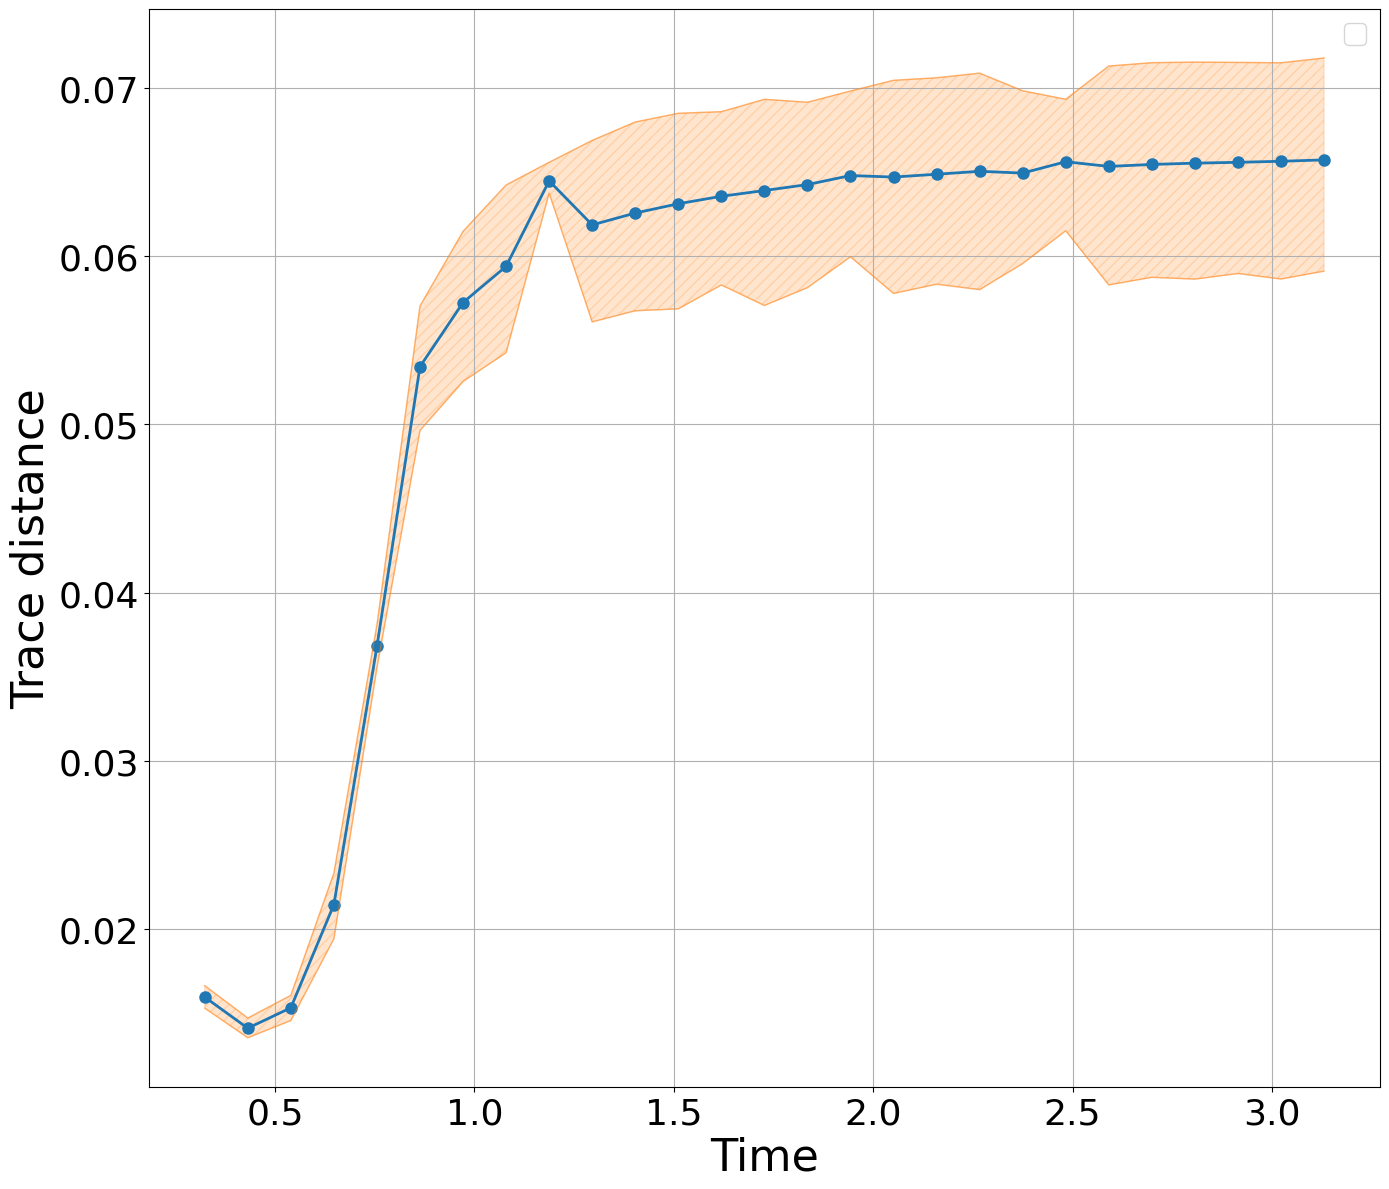

In [7]:
import pandas as pd

# --- Moving Statistics ---
def moving_average(x, window=5):
    return np.convolve(x, np.ones(window)/window, mode='valid')

def moving_max(x, window=5):
    return sliding_window_view(x, window).max(axis=1)

def moving_min(x, window=5):
    return sliding_window_view(x, window).min(axis=1)

t = np.asarray(times, float)
window = 10
results = []
n=3
for i, kappa in enumerate(kappa_vals[n:]):
    i+=n
    ratio = kappa / (1/np.sqrt(dim_N1))
    y = np.asarray(D_mean[i], float)
    half = len(y) // 2
    y_latter = y[half:]

    windows = sliding_window_view(y_latter, window)
    y_ma  = windows.mean(axis=1)
    y_max = windows.max(axis=1)
    y_min = windows.min(axis=1)

    results.append({
        'g/sigma': ratio,
        'td':      y_ma.mean(),
        'td_max':  y_max.mean(),
        'td_min':  y_min.mean(),
    })

df = pd.DataFrame(results).sort_values('g/sigma')

# --- Plot ---
plt.figure(figsize=(14, 12))

plt.plot(df['g/sigma'], df['td'], 'o-', linewidth=2, markersize=8)
line, = plt.plot(df['g/sigma'], df['td_max'], '-', linewidth=1, alpha=0.5)
color = line.get_color()
plt.plot(df['g/sigma'], df['td_min'], '-', color=color, linewidth=1, alpha=0.5)
plt.fill_between(df['g/sigma'], df['td_min'], df['td_max'], color=color, alpha=0.2, hatch='///')

plt.xlabel(r'Time', fontsize=32)
plt.ylabel('Trace distance', fontsize=32)
plt.legend(fontsize=20)
plt.tick_params(axis='both', which='major', labelsize=26)
plt.grid(True)
plt.tight_layout()
plt.show()
